DBSCAN

In [119]:
import seaborn as sns
from sklearn.datasets  import make_moons
from sklearn.cluster import DBSCAN
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import numpy as np

In [54]:
X,y = make_moons(n_samples=300, noise=0.1, random_state=42)

<Axes: >

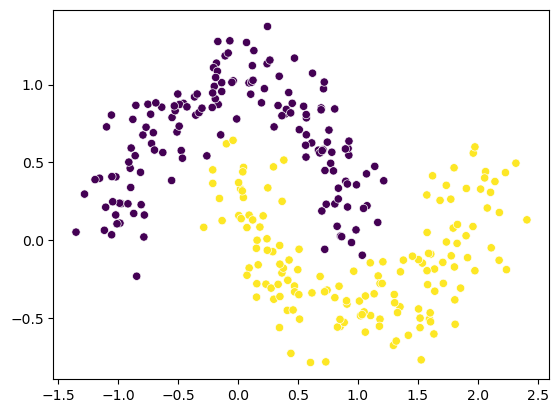

In [33]:
sns.scatterplot(x=X[:,0], y=X[:,1], c=y)

In [55]:
dbscan = DBSCAN(eps=0.15, min_samples=4)
label = dbscan.fit_predict(X)

<Axes: >

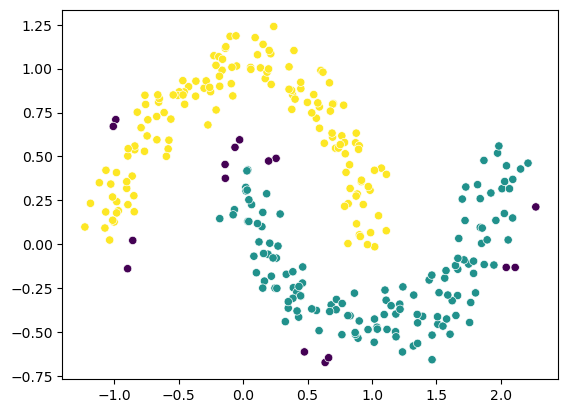

In [56]:
sns.scatterplot(x=X[:,0], y=X[:,1], c=label)

Isolation Forest

In [137]:
data = pd.read_csv("thyroid.csv", sep=";")

data=data.drop(["Unnamed: 22", "Unnamed: 23"], axis=1)

In [138]:
X = data.drop(["Outlier_label"], axis=1)
y = data["Outlier_label"].map({"o":0, "n":1})

In [105]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [122]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [153]:
iso_forest = IsolationForest(n_estimators=200, random_state=42, contamination=0.036)
label = iso_forest.fit_predict(X_scaled)

<Axes: >

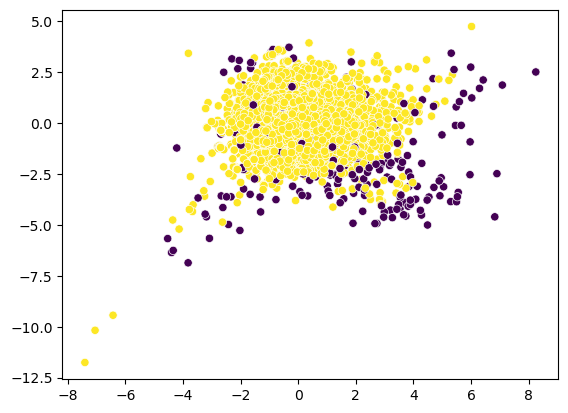

In [154]:
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], c=label)

<Axes: >

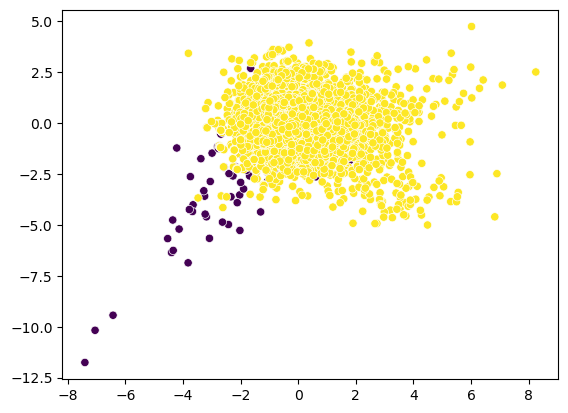

In [155]:
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], c=y)

In [156]:
outliers = np.sum(label==-1)
outliers_original = np.sum(y==0)

In [157]:
print(f"outliers = {outliers_original}, predicted outliers = {outliers}")

outliers = 250, predicted outliers = 249


Local Outlier Factor

In [158]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(contamination=0.036)
labels = lof.fit_predict(X_scaled)

c:\Users\muska\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\muska\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\muska\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\muska\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

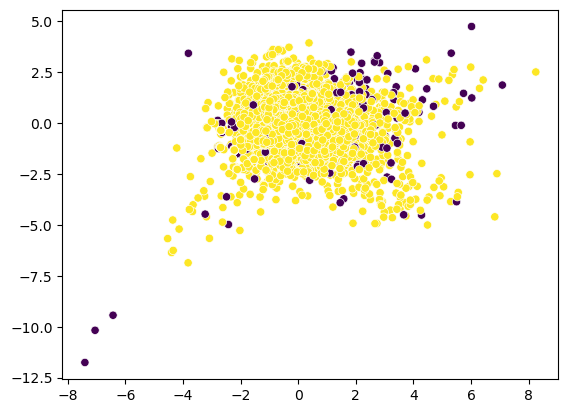

In [160]:
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], c=labels)
outlier = np.sum(labels==-1)

In [161]:
outlier

np.int64(249)